# 03 — Weather Impact on SIKD Performance: Vietnam & ASEAN

Phân tích ảnh hưởng của thời tiết nhiệt đới lên hiệu năng SIKD.

## Nội dung
1. Monthly weather profiles — 8 ASEAN cities
2. SKR_effective theo tháng (wet vs dry season)
3. Atmospheric transmission hl theo tháng
4. Cloud outage impact: SKR_clear vs SKR_effective
5. SKR heatmap: ASEAN cities × months
6. Availability analysis

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from modules.weather_model import (
    ASEAN_CLIMATE_DATA, CITY_COORDS, MONTHS,
    get_city_params, get_all_months, get_season,
    compute_seasonal_hl, compute_effective_skr,
    compute_effective_skr_3state,
    compute_link_availability, compute_annual_stats,
    RAIN_FRACTION_DEFAULT,
)
from modules.channel_model import compute_channel, compute_hl
from modules.sikd_performance import compute_sikd_performance

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})

CITIES = ['hanoi', 'hcmc', 'danang', 'bangkok',
          'singapore', 'manila', 'jakarta', 'kuala_lumpur']
CITY_LABELS = ['Hanoi', 'HCMC', 'Da Nang', 'Bangkok',
               'Singapore', 'Manila', 'Jakarta', 'KL']
ZETA_DEG = 45.0
PARAMS = dict(PT=1.0, mK=0.05, mD=0.5, Iso_dB=15.0, zeta_scale=2.0, Rb=1e9)
H_S_KM = 500.0

print('Modules loaded OK')
print(f'Using: PT={PARAMS["PT"]}W, Iso={PARAMS["Iso_dB"]}dB, H_S={H_S_KM}km')
print(f'Model: 3-state (clear/rain/cloud) with rain_fraction={RAIN_FRACTION_DEFAULT}')

Modules loaded OK
Using: PT=1.0W, Iso=15.0dB, H_S=500.0km
Model: 3-state (clear/rain/cloud) with rain_fraction=0.15


## 1. Monthly Rainfall Profiles — Vietnam Cities

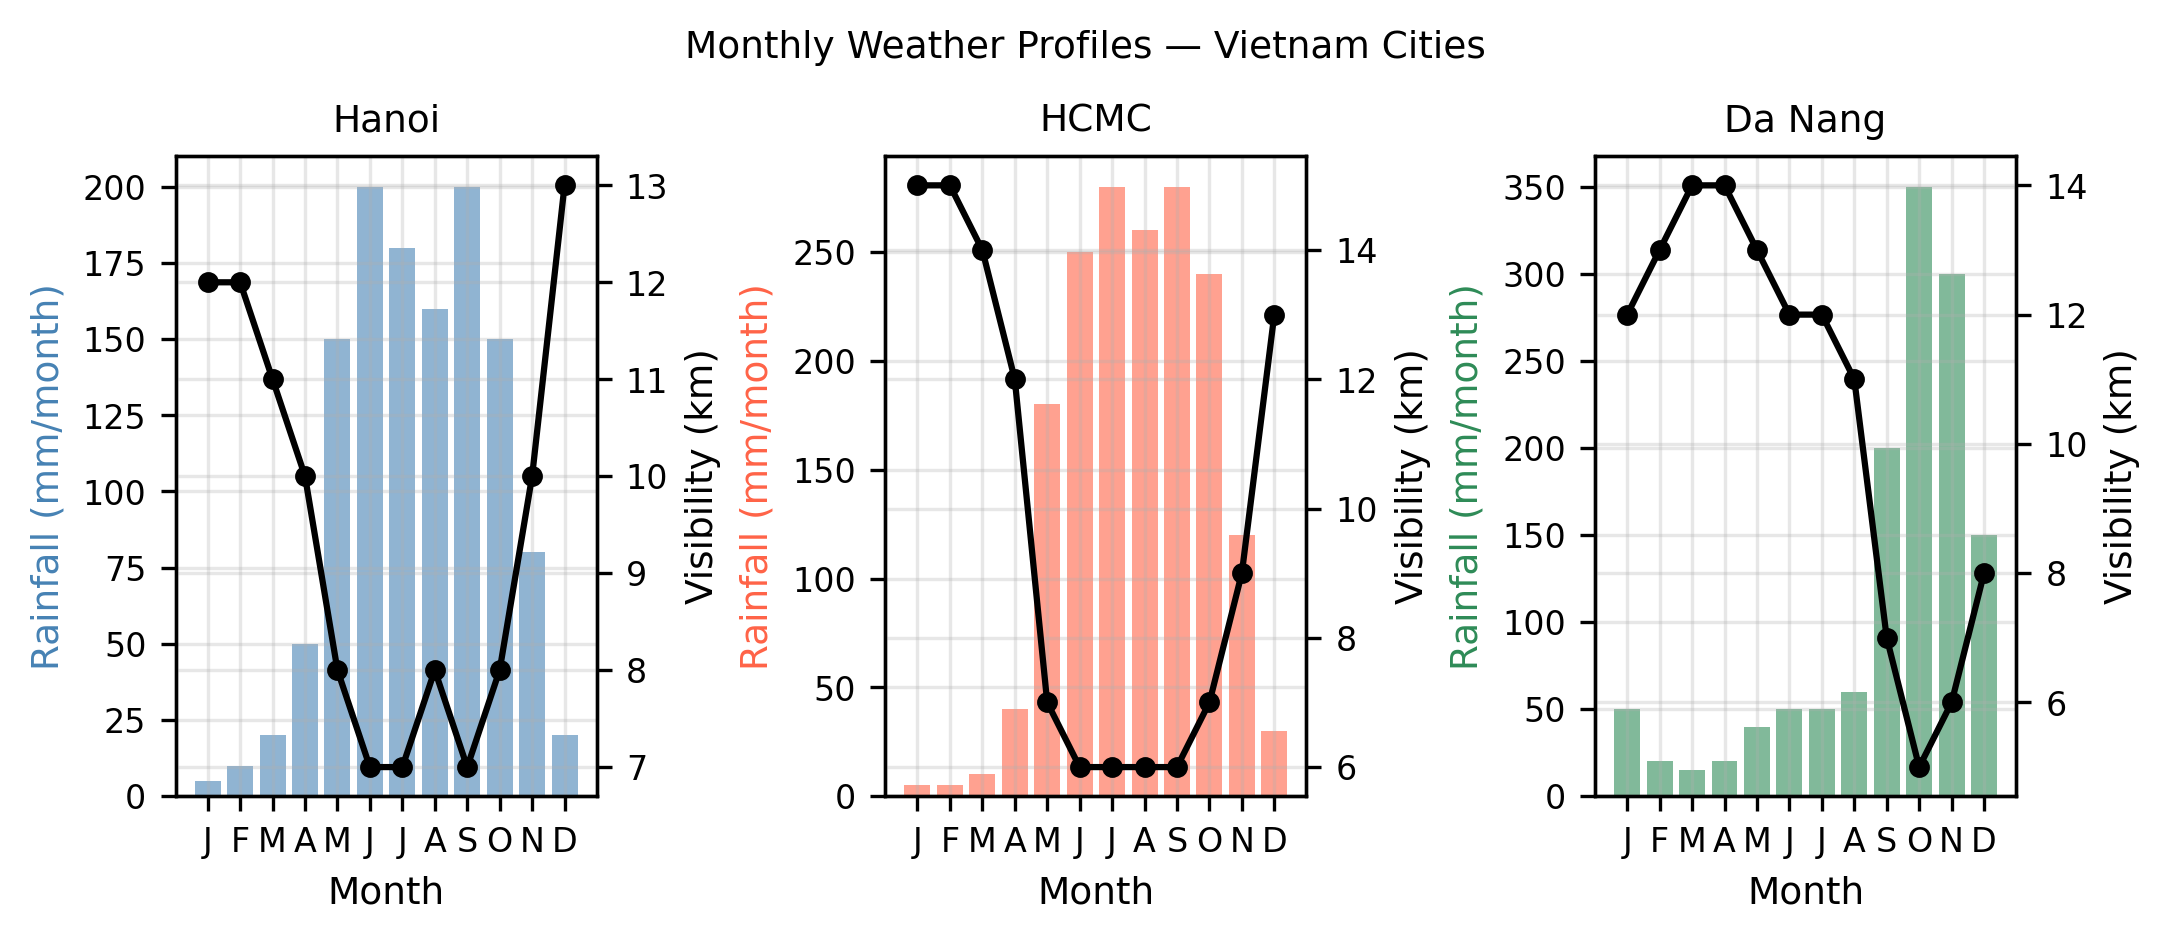

In [2]:
vn_cities = ['hanoi', 'hcmc', 'danang']
vn_labels = ['Hanoi', 'HCMC', 'Da Nang']
colors    = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(7.16, 3.0), sharey=False)

for ax, city, label, color in zip(axes, vn_cities, vn_labels, colors):
    months_data = get_all_months(city)
    R_vals = [m['R_mm_month'] for m in months_data]
    V_vals = [m['V_km'] for m in months_data]
    P_vals = [m['P_cloud'] for m in months_data]
    x = np.arange(1, 13)

    ax2 = ax.twinx()
    ax.bar(x, R_vals, color=color, alpha=0.6, label='R (mm/month)')
    ax2.plot(x, V_vals, 'k-o', markersize=4, label='V (km)')
    ax.set_title(label)
    ax.set_xlabel('Month')
    ax.set_ylabel('Rainfall (mm/month)', color=color)
    ax2.set_ylabel('Visibility (km)')
    ax.set_xticks(x)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

plt.suptitle('Monthly Weather Profiles — Vietnam Cities', fontsize=9, y=1.0)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig07_vietnam_weather_profiles.png', bbox_inches='tight', dpi=300)
plt.show()

## 2. SKR_effective theo tháng — tất cả 8 thành phố

In [3]:
def compute_skr_3state(city, month, zeta_deg=ZETA_DEG):
    """Tính SKR theo mô hình 3 trạng thái cho một thành phố và tháng.
    
    3 trạng thái:
      1. Trời quang (p1): R=0, V=V_km → hl_clear → SKR_clear
      2. Mưa (p2=rain_fraction): R=R_mm_h, V=V_km → hl_rain → SKR_rain
      3. Mây dày (p3=P_cloud): link OFF → SKR=0
    
    SKR_effective = p1 × SKR_clear + p2 × SKR_rain
    """
    wx = get_city_params(city, month)
    ch = compute_channel(H_S_KM, zeta_deg)
    
    # State 1: Clear sky (no rain)
    hl_clear = compute_hl(zeta_deg=zeta_deg, V_km=wx['V_km'], R_mm_h=0.0)
    p_clear = compute_sikd_performance(
        hg=ch['hg'], hl=hl_clear, sigma_X2=ch['sigma_X2'], **PARAMS
    )
    skr_clear = p_clear['SKR_kbps']
    
    # State 2: Rain
    hl_rain = compute_hl(zeta_deg=zeta_deg, V_km=wx['V_km'], R_mm_h=wx['R_mm_h'])
    p_rain = compute_sikd_performance(
        hg=ch['hg'], hl=hl_rain, sigma_X2=ch['sigma_X2'], **PARAMS
    )
    skr_rain = p_rain['SKR_kbps']
    
    # 3-state weighted average
    result = compute_effective_skr_3state(
        skr_clear=skr_clear, skr_rain=skr_rain,
        P_cloud=wx['P_cloud'], rain_fraction=RAIN_FRACTION_DEFAULT
    )
    
    return {
        'skr_clear': skr_clear,
        'skr_rain': skr_rain,
        'skr_effective': result['skr_effective'],
        'hl_clear': hl_clear,
        'hl_rain': hl_rain,
        'P_cloud': wx['P_cloud'],
        'p_clear': result['p_clear'],
        'p_rain': result['p_rain'],
        'qber_clear': p_clear['QBER'],
        'qber_rain': p_rain['QBER'],
    }

# Compute for all cities × 12 months
skr_clear_all = np.zeros((len(CITIES), 12))
skr_rain_all  = np.zeros((len(CITIES), 12))
skr_eff_all   = np.zeros((len(CITIES), 12))
p_cloud_all   = np.zeros((len(CITIES), 12))
hl_clear_all  = np.zeros((len(CITIES), 12))
hl_rain_all   = np.zeros((len(CITIES), 12))

for i, city in enumerate(CITIES):
    for m in range(1, 13):
        r = compute_skr_3state(city, m)
        skr_clear_all[i, m-1] = r['skr_clear']
        skr_rain_all[i, m-1]  = r['skr_rain']
        skr_eff_all[i, m-1]   = r['skr_effective']
        p_cloud_all[i, m-1]   = r['P_cloud']
        hl_clear_all[i, m-1]  = r['hl_clear']
        hl_rain_all[i, m-1]   = r['hl_rain']

print('3-state SKR computation done')
print(f'Max SKR_clear: {skr_clear_all.max():.1f} kbps')
print(f'Max SKR_effective: {skr_eff_all.max():.1f} kbps')
print(f'Min SKR_effective: {skr_eff_all.min():.1f} kbps')
print(f'\nHanoi July: SKR_clear={skr_clear_all[0,6]:.1f}, SKR_rain={skr_rain_all[0,6]:.1f}, SKR_eff={skr_eff_all[0,6]:.1f} kbps')

3-state SKR computation done
Max SKR_clear: 13353.7 kbps
Max SKR_effective: 11348.6 kbps
Min SKR_effective: 209.1 kbps

Hanoi July: SKR_clear=12714.3, SKR_rain=33.4, SKR_eff=3819.3 kbps


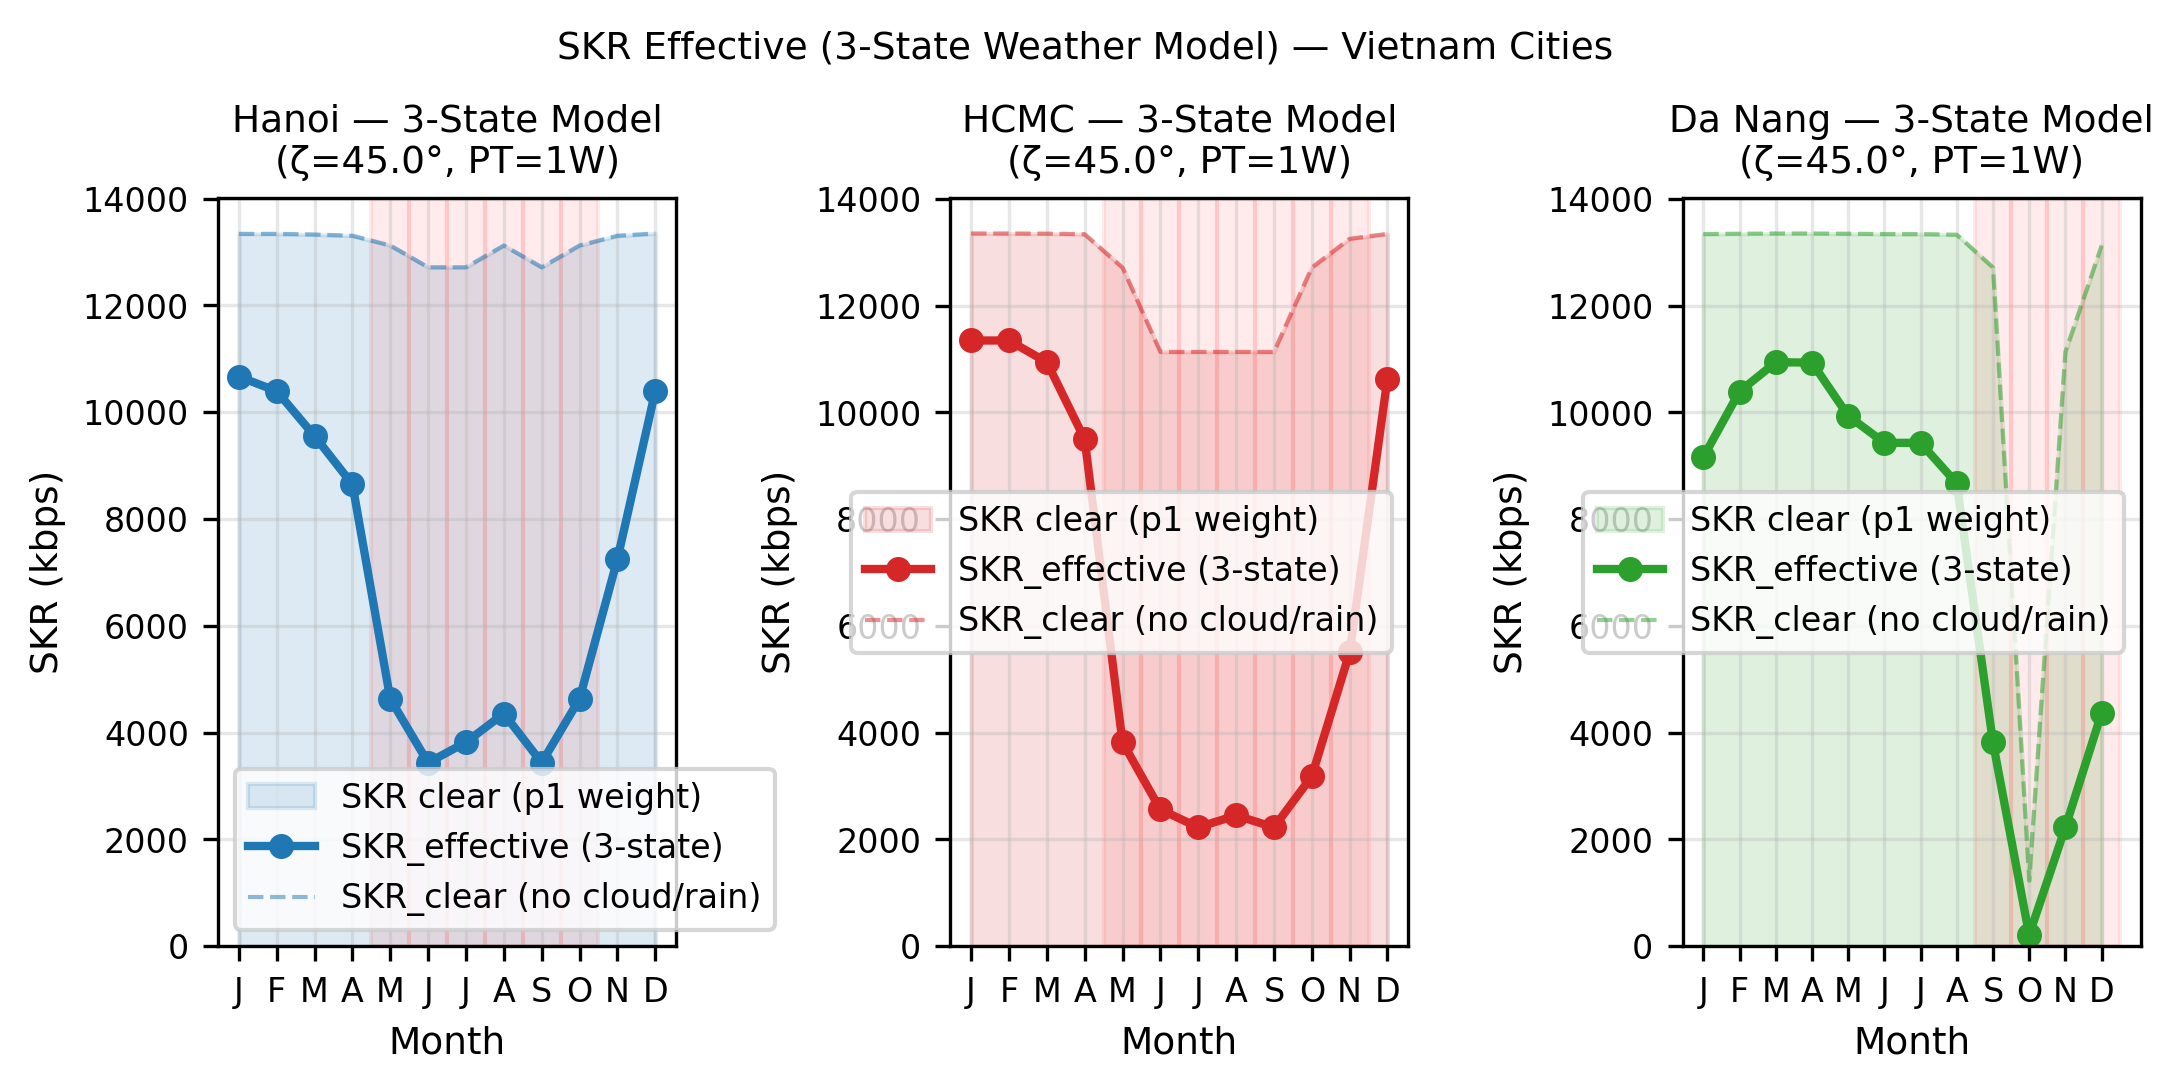

Red shading = wet season months (R > 100 mm/month)


In [4]:
# Plot SKR — 3-state model for Vietnam cities
fig, axes = plt.subplots(1, 3, figsize=(7.16, 3.5))
x = np.arange(1, 13)

for ax, city, label, color in zip(axes,
        ['hanoi', 'hcmc', 'danang'],
        ['Hanoi', 'HCMC', 'Da Nang'],
        ['#1f77b4', '#d62728', '#2ca02c']):
    idx = CITIES.index(city)
    
    ax.fill_between(x, 0, skr_clear_all[idx], alpha=0.15, color=color, label='SKR clear (p1 weight)')
    ax.plot(x, skr_eff_all[idx], '-o', color=color, markersize=5, linewidth=2,
            label='SKR_effective (3-state)')
    ax.plot(x, skr_clear_all[idx], '--', color=color, alpha=0.5, linewidth=1,
            label='SKR_clear (no cloud/rain)')
    
    # Mark wet months
    for m in range(12):
        if get_season(city, m+1) == 'wet':
            ax.axvspan(m+0.5, m+1.5, alpha=0.08, color='red')
    
    ax.set_xlabel('Month')
    ax.set_ylabel('SKR (kbps)')
    ax.set_title(f'{label} — 3-State Model\n(ζ={ZETA_DEG}°, PT=1W)')
    ax.set_xticks(x)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.suptitle('SKR Effective (3-State Weather Model) — Vietnam Cities', fontsize=9, y=1.0)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig08_skr_monthly_vietnam.png', bbox_inches='tight', dpi=300)
plt.show()
print('Red shading = wet season months (R > 100 mm/month)')

## 3. SKR Heatmap: ASEAN Cities × Months

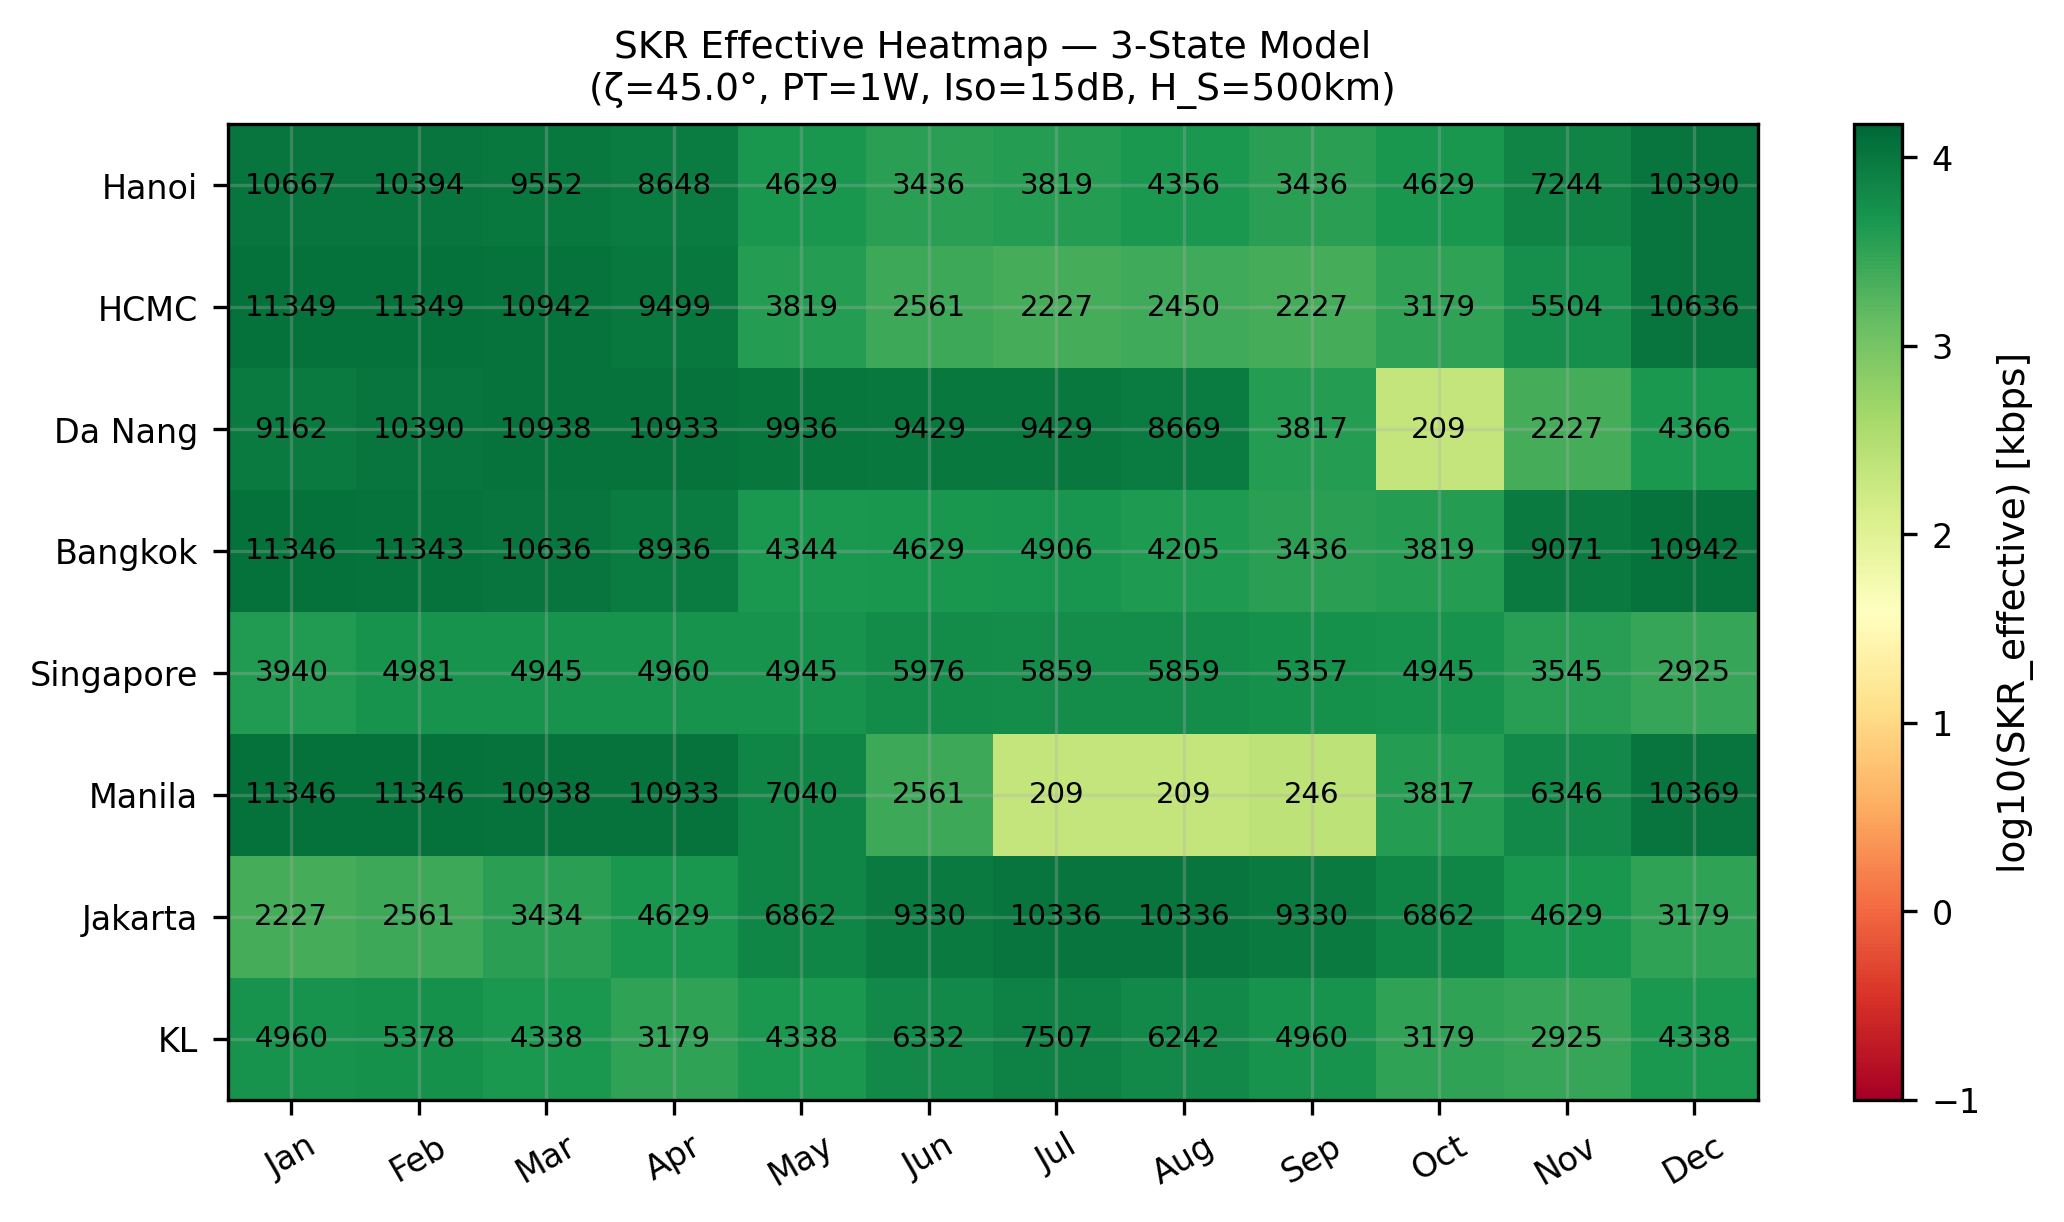

In [5]:
fig, ax = plt.subplots(figsize=(7.16, 4.0))

# Use log scale for color — 3-state effective SKR
skr_log = np.log10(np.where(skr_eff_all > 0, skr_eff_all, 1e-10))

im = ax.imshow(skr_log, aspect='auto', cmap='RdYlGn',
               vmin=-1, vmax=np.log10(15000))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('log10(SKR_effective) [kbps]')

ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS, rotation=30)
ax.set_yticks(range(len(CITIES)))
ax.set_yticklabels(CITY_LABELS)
ax.set_title(f'SKR Effective Heatmap — 3-State Model\n(ζ={ZETA_DEG}°, PT=1W, Iso=15dB, H_S=500km)')

# Annotate with actual values
for i in range(len(CITIES)):
    for j in range(12):
        val = skr_eff_all[i, j]
        txt = f'{val:.0f}' if val >= 1 else f'{val:.2f}'
        color = 'white' if skr_log[i, j] < 2 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig09_skr_heatmap_asean.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. Atmospheric Transmission hl theo tháng

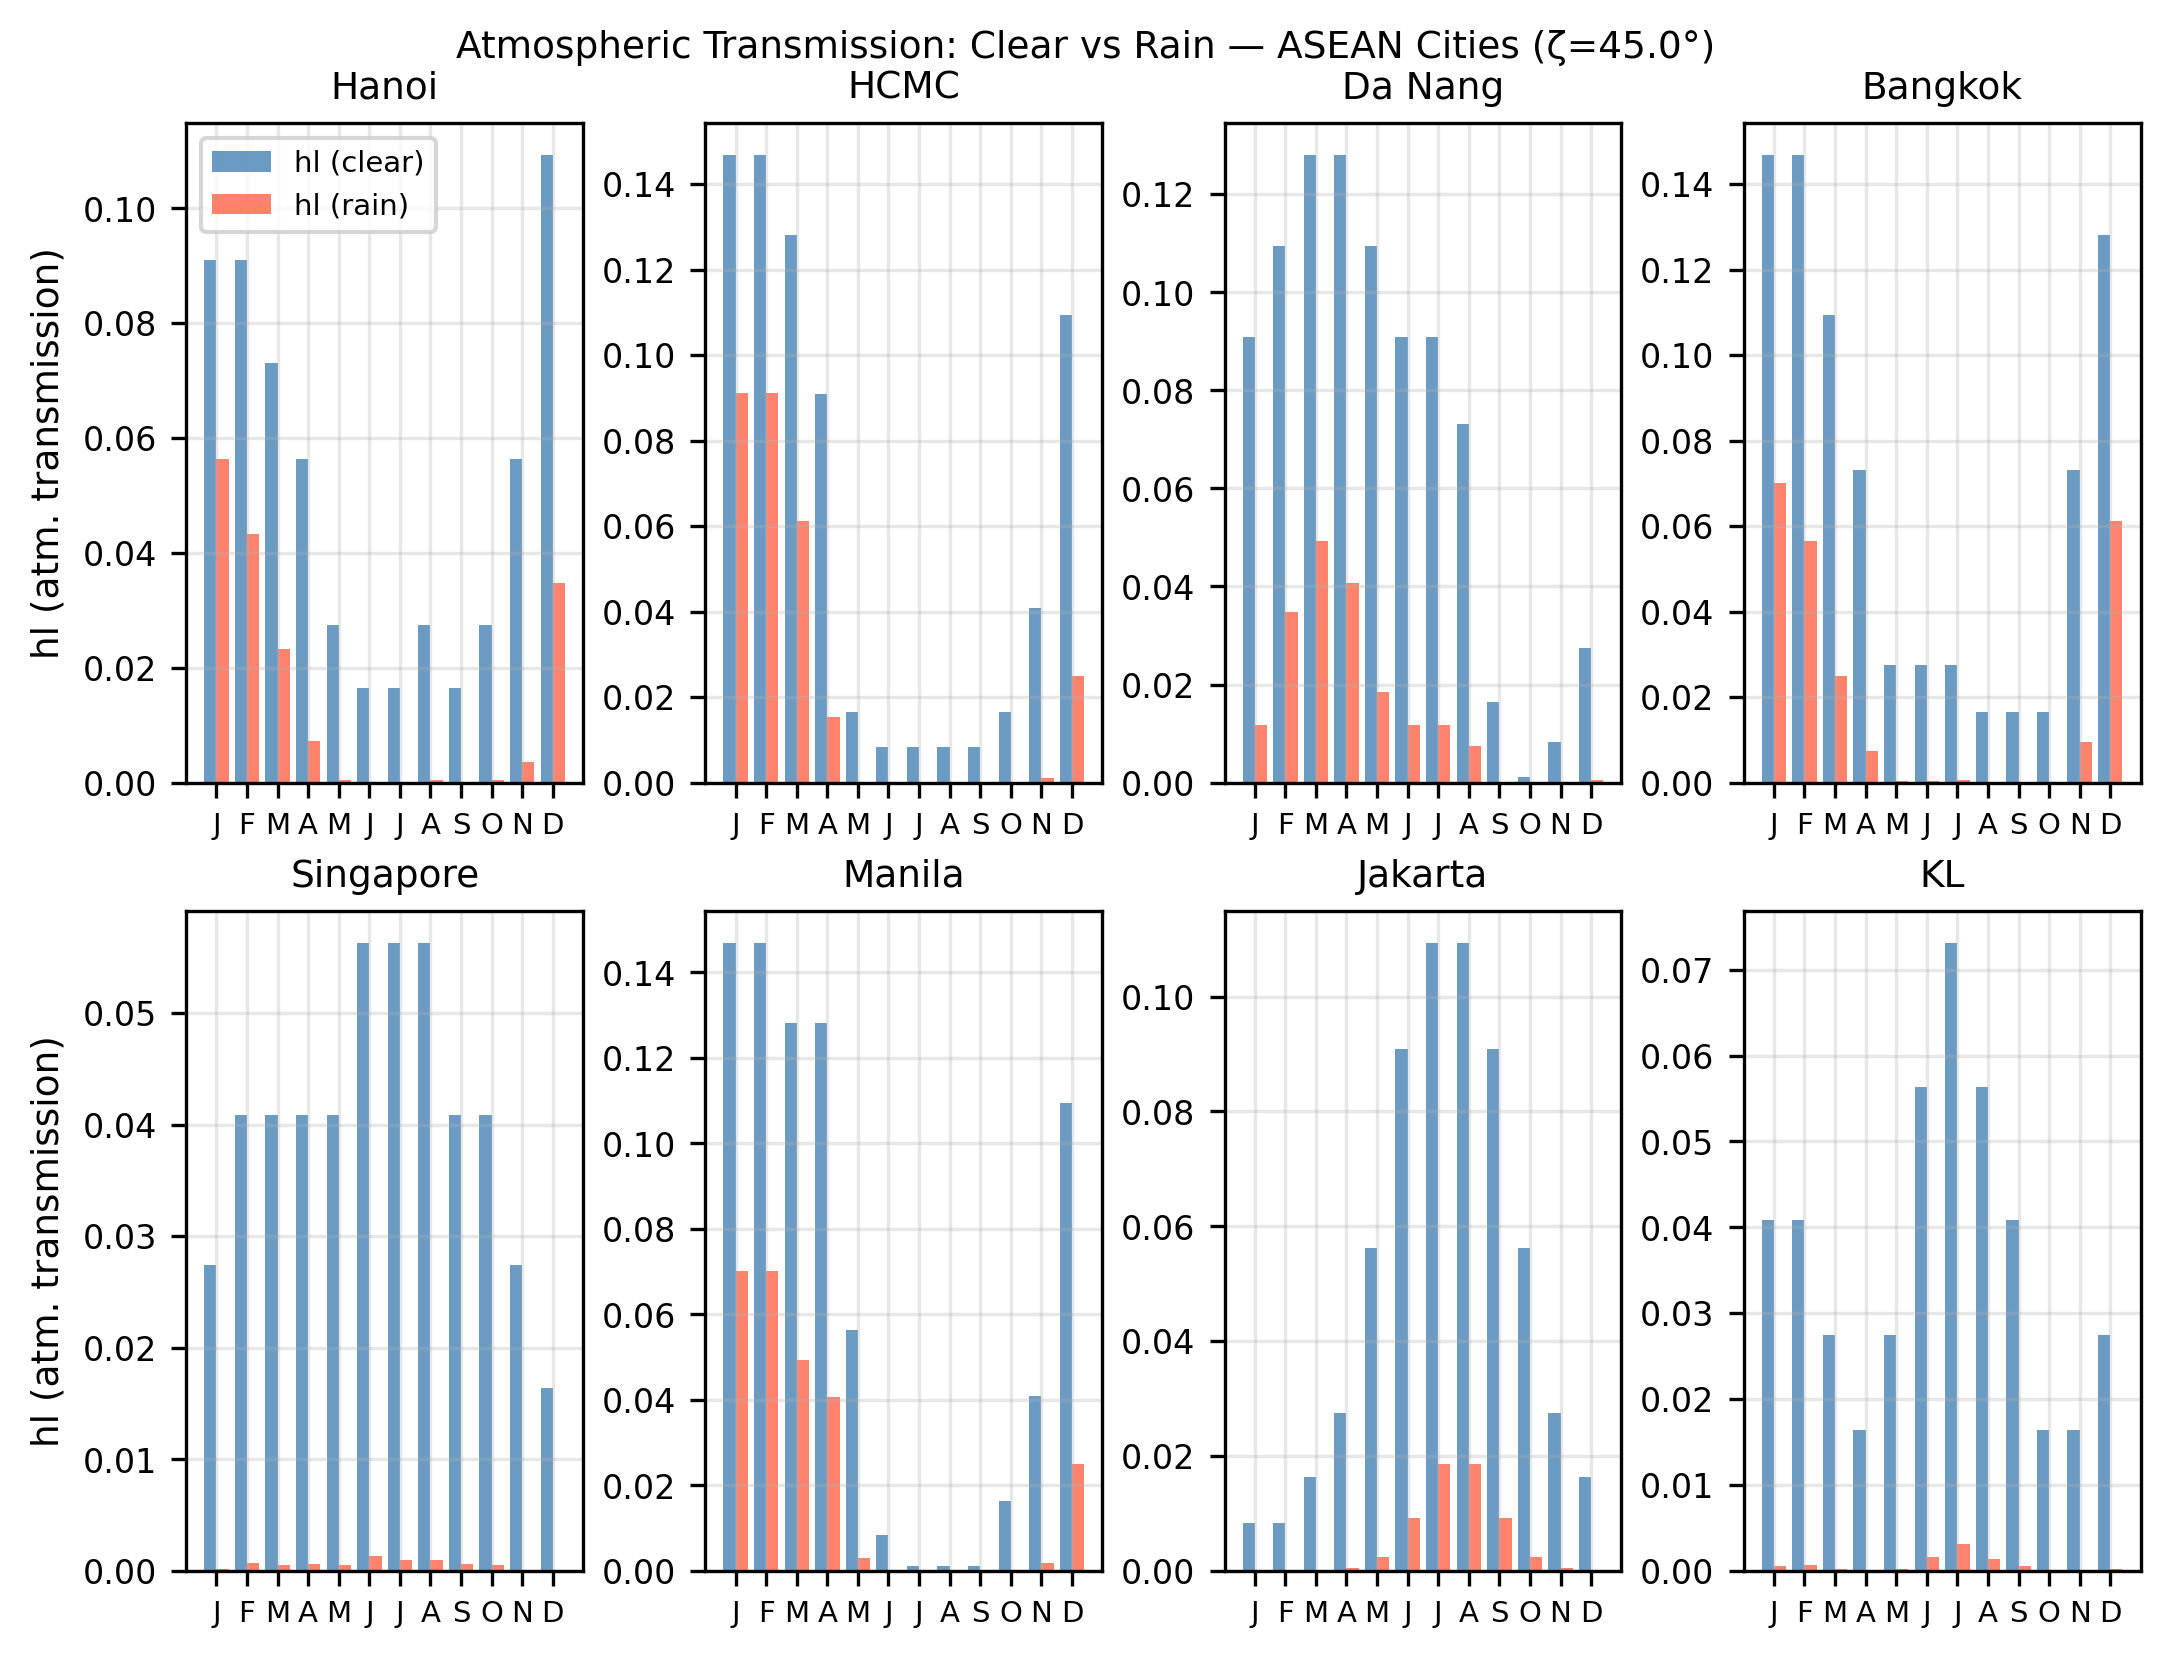

Blue = hl without rain (clear sky), Red = hl with rain
Hanoi Jul: hl_clear=0.0164, hl_rain=0.000169 (ratio=97x)


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(7.16, 5.5))
axes = axes.flatten()
x = np.arange(1, 13)

for ax, city, label, idx in zip(axes, CITIES, CITY_LABELS, range(len(CITIES))):
    # hl_clear (no rain) vs hl_rain (with rain)
    hl_c = hl_clear_all[idx]
    hl_r = hl_rain_all[idx]
    
    seasons = [get_season(city, m) for m in range(1, 13)]
    
    ax.bar(x - 0.2, hl_c, 0.4, color='steelblue', alpha=0.8, label='hl (clear)')
    ax.bar(x + 0.2, hl_r, 0.4, color='tomato', alpha=0.8, label='hl (rain)')
    
    ax.set_title(label, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)
    ax.set_ylim(bottom=0)
    if idx == 0 or idx == 4:
        ax.set_ylabel('hl (atm. transmission)')
    if idx == 0:
        ax.legend(fontsize=7)

plt.suptitle(f'Atmospheric Transmission: Clear vs Rain — ASEAN Cities (ζ={ZETA_DEG}°)', fontsize=9)
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig10_hl_monthly_asean.png', bbox_inches='tight', dpi=300)
plt.show()
print('Blue = hl without rain (clear sky), Red = hl with rain')
print(f'Hanoi Jul: hl_clear={hl_clear_all[0,6]:.4f}, hl_rain={hl_rain_all[0,6]:.6f} (ratio={hl_clear_all[0,6]/max(hl_rain_all[0,6],1e-20):.0f}x)')

## 5. Annual Statistics Summary

In [7]:
import pandas as pd

rows = []
for i, (city, label) in enumerate(zip(CITIES, CITY_LABELS)):
    skr_by_month = list(skr_clear_all[i])
    stats = compute_annual_stats(city, skr_by_month)

    # Effective annual mean
    eff_mean = float(np.mean(skr_eff_all[i]))
    avail_mean = float(np.mean(1.0 - p_cloud_all[i]))

    rows.append({
        'City': label,
        'SKR_clear_mean (kbps)': f"{stats['skr_annual_mean']:.4f}",
        'SKR_eff_mean (kbps)':   f"{eff_mean:.4f}",
        'SKR_wet_mean (kbps)':   f"{stats['skr_wet_mean']:.4f}",
        'SKR_dry_mean (kbps)':   f"{stats['skr_dry_mean']:.4f}",
        'Availability (%)':      f"{avail_mean*100:.1f}",
        'Wet months': len(stats['wet_months']),
        'Dry months': len(stats['dry_months']),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     City SKR_clear_mean (kbps) SKR_eff_mean (kbps) SKR_wet_mean (kbps) SKR_dry_mean (kbps) Availability (%)  Wet months  Dry months
    Hanoi            13122.8356           6766.5965          12918.4036          13327.2675             59.6           6           6
     HCMC            12497.3869           6311.8905          11889.0494          13349.0595             57.4           7           5
  Da Nang            12078.8107           7458.8752           9550.5278          13342.9521             63.2           4           8
  Bangkok            13130.9588           7301.1265          12918.4036          13343.5139             63.1           6           6
Singapore            13199.3413           4852.9077          13199.3413              0.0000             51.2          12           0
   Manila            10071.1143           6280.1772           5507.8745          13330.5712             59.7           5           7
  Jakarta            12827.2478           6143.0459          12324.06

## 6. Wet vs Dry Season SKR Comparison

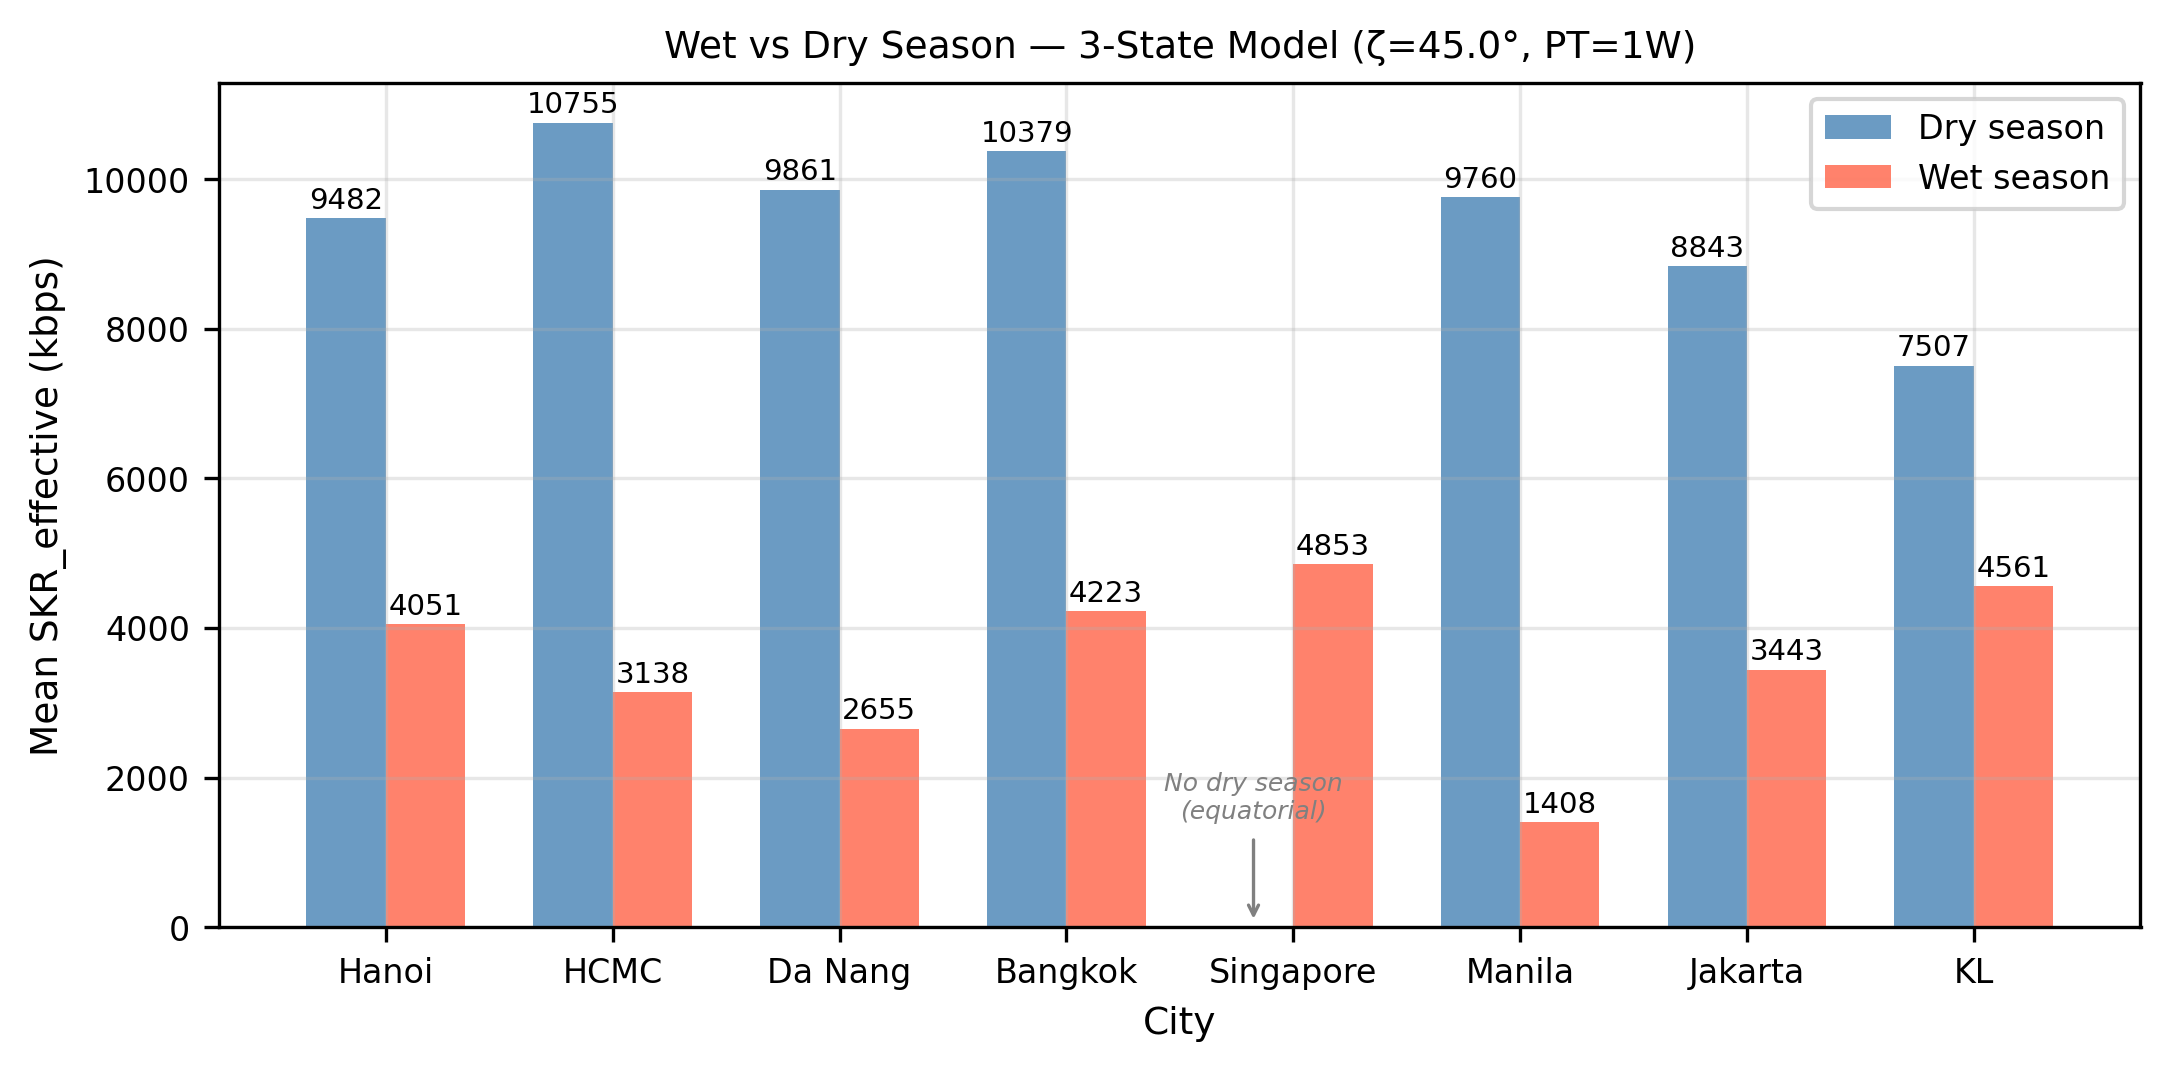


Dry/Wet ratio:
  Hanoi       : dry=9482, wet=4051, ratio=2.3x
  HCMC        : dry=10755, wet=3138, ratio=3.4x
  Da Nang     : dry=9861, wet=2655, ratio=3.7x
  Bangkok     : dry=10379, wet=4223, ratio=2.5x
  Singapore   : dry=0, wet=4853, ratio=0.0x
  Manila      : dry=9760, wet=1408, ratio=6.9x
  Jakarta     : dry=8843, wet=3443, ratio=2.6x
  KL          : dry=7507, wet=4561, ratio=1.6x


In [8]:
wet_means = []
dry_means = []

for i, city in enumerate(CITIES):
    wet_idx = [m-1 for m in range(1, 13) if get_season(city, m) == 'wet']
    dry_idx = [m-1 for m in range(1, 13) if get_season(city, m) == 'dry']
    wet_means.append(np.mean(skr_eff_all[i, wet_idx]) if wet_idx else 0)
    dry_means.append(np.mean(skr_eff_all[i, dry_idx]) if dry_idx else 0)

x = np.arange(len(CITIES))
width = 0.35

fig, ax = plt.subplots(figsize=(7.16, 3.5))
bars1 = ax.bar(x - width/2, dry_means,  width, label='Dry season', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, wet_means,  width, label='Wet season', color='tomato',    alpha=0.8)

# Add value labels
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:.0f}',
                ha='center', va='bottom', fontsize=7)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:.0f}',
                ha='center', va='bottom', fontsize=7)

# Annotate Singapore (equatorial climate — no dry season)
sing_idx = CITY_LABELS.index('Singapore') if 'Singapore' in CITY_LABELS else None
if sing_idx is not None:
    ax.annotate('No dry season\n(equatorial)', xy=(sing_idx - width/2, 0),
                xytext=(sing_idx - width/2, max(wet_means)*0.3),
                fontsize=6, ha='center', color='gray', fontstyle='italic',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('City')
ax.set_ylabel('Mean SKR_effective (kbps)')
ax.set_title(f'Wet vs Dry Season — 3-State Model (ζ={ZETA_DEG}°, PT=1W)')
ax.set_xticks(x)
ax.set_xticklabels(CITY_LABELS)
ax.legend()
plt.tight_layout(pad=0.5)
plt.savefig('diagrams/fig11_wet_dry_skr_comparison.png', bbox_inches='tight', dpi=450)
plt.show()

# Print ratio
print('\nDry/Wet ratio:')
for label, d, w in zip(CITY_LABELS, dry_means, wet_means):
    ratio = d/w if w > 0 else float('inf')
    print(f'  {label:12s}: dry={d:.0f}, wet={w:.0f}, ratio={ratio:.1f}x')